# Dataset and Chunk Analysis

## Goal

This notebook explores the MultiHop-RAG dataset and analyzes
the document chunking strategy before building retrieval systems.

The objective is to understand:

- QA structure
- Corpus structure
- Document statistics
- Chunk distribution
- Potential data quality issues

This analysis will guide retrieval pipeline decisions.

In [1]:
import json
from collections import Counter
from statistics import mean

from datasets import load_dataset

import matplotlib.pyplot as plt

d:\app\ai\adaptive-agentic-rag\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
qa_dataset = load_dataset(
    "yixuantt/MultiHopRAG",
    "MultiHopRAG"
)

qa = qa_dataset["train"]

print(qa)

Dataset({
    features: ['evidence_list', 'answer', 'query', 'question_type'],
    num_rows: 2556
})


In [3]:
qa[0]

{'evidence_list': [{'author': 'Elizabeth Lopatto',
   'category': 'technology',
   'fact': 'Before his fall, Bankman-Fried made himself out to be the Good Boy of crypto — the trustworthy face of a sometimes-shady industry.',
   'published_at': '2023-09-28 12:00:00',
   'source': 'The Verge',
   'title': 'The FTX trial is bigger than Sam Bankman-Fried',
   'url': 'https://www.theverge.com/2023/9/28/23893269/ftx-sam-bankman-fried-trial-evidence-crypto'},
  {'author': 'Jacquelyn Melinek',
   'category': 'technology',
   'fact': 'The highly anticipated criminal trial for Sam Bankman-Fried, former CEO of bankrupt crypto exchange FTX, started Tuesday to determine whether he’s guilty of seven counts of fraud and conspiracy.',
   'published_at': '2023-10-01 14:00:29',
   'source': 'TechCrunch',
   'title': 'SBF’s trial starts soon, but how did he — and FTX — get here?',
   'url': 'https://techcrunch.com/2023/10/01/ftx-lawsuit-timeline/'},
  {'author': 'Kyle Wiggers',
   'category': 'technology

In [4]:
question_types = Counter(
    qa["question_type"]
)

question_types

Counter({'comparison_query': 856,
         'inference_query': 816,
         'temporal_query': 583,
         'null_query': 301})

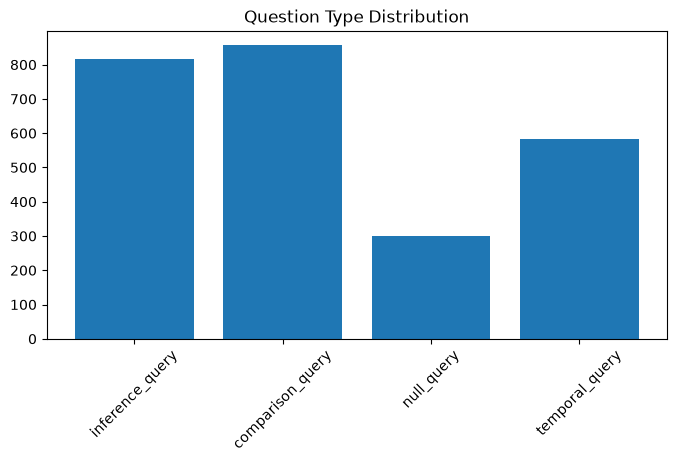

In [5]:
plt.figure(figsize=(8,4))

plt.bar(
    question_types.keys(),
    question_types.values()
)

plt.xticks(rotation=45)

plt.title(
    "Question Type Distribution"
)

plt.show()

In [6]:
with open(
    "../data/processed/processed_corpus.json",
    "r",
    encoding="utf-8"
) as f:

    chunks = json.load(f)


len(chunks)

3883

In [7]:
chunk_lengths = [
    len(chunk["text"].split())
    for chunk in chunks
]


print(
    "Average:",
    mean(chunk_lengths)
)


print(
    "Min:",
    min(chunk_lengths)
)


print(
    "Max:",
    max(chunk_lengths)
)

Average: 281.27839299510686
Min: 1
Max: 420


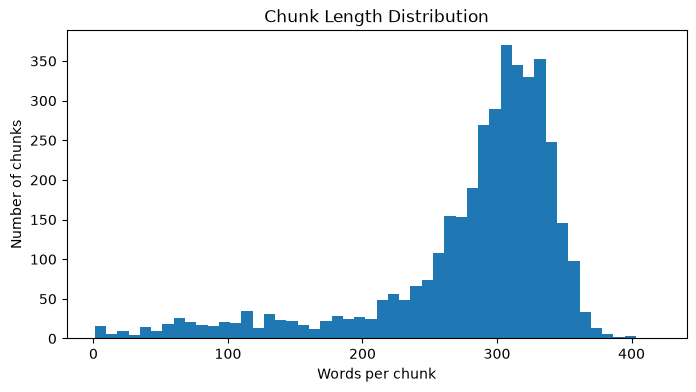

In [8]:
plt.figure(figsize=(8,4))

plt.hist(
    chunk_lengths,
    bins=50
)

plt.xlabel(
    "Words per chunk"
)

plt.ylabel(
    "Number of chunks"
)

plt.title(
    "Chunk Length Distribution"
)

plt.show()

In [9]:
small_chunks = [
    chunk
    for chunk in chunks
    if len(chunk["text"].split()) < 10
]


len(small_chunks)

16

In [10]:
for chunk in small_chunks[:10]:

    print("----------------")

    print(
        chunk["text"]
    )

----------------
Loading . . .
----------------
Loading . . .
----------------
Advertisement
----------------
Advertisement
----------------
Advertisement
----------------
Advertisement
----------------
Advertisement
----------------
Advertisement
----------------
Advertisement
----------------
Advertisement


In [11]:
for chunk in chunks[100:103]:

    print("----------------")

    print(
        chunk["text"][:500]
    )

----------------
In March 2022, Will slapped Chris Rock at the 94th annual Oscars before he yelled at the comedian to “keep my wife’s name out your f***ing mouth”. It quickly became the most talked-about moment of the evening with the pair initially appearing to laugh off the tense moment.

The altercation came after Rock said: “Jada, I love you. GI Jane 2, can’t wait to see you,” referring to Jada’s shaved head. While accepting the award for Best Actor, Will became teary as said he was a “fierce defender of his
----------------
Country music couples have serenaded their way into each other’s hearts for years.

Much like the resilient love story of Tim McGraw and Faith Hill or Garth Brooks and Trisha Yearwood, there's a sweet melody in the lives of several country music stars who have weathered the storms of fame while creating strong bonds in their lasting romances.

Beyond the stage lights, these loving country music couples – or musicians and their long-lasting partners – have prove

# Chunking Decision

Based on the analysis:

- The initial chunking strategy produced overly fragmented chunks.
- Increasing chunk size reduced unnecessary fragmentation.
- The final configuration:

chunk_size = 2000 characters
chunk_overlap = 200 characters

resulted in:

- 3883 chunks
- average chunk length around 281 words

This configuration will be used as the baseline for retrieval experiments.